Notebook realizado por Juan David Sánchez. Contacto: juan.sanchez34@udea.edu.co

# **Sesión 5 - Espacio químico**

El dataset 1 contiene información acerca de las moléculas con bioactividad reportada frente al target Proteína Precursora Amiloidea (APP), el cual fue obtenido a partir de la base de datos PubChem.

El dataset 2 es una base de datos curada por DIFACQUIM.

El dataset 3 contiene información acerca de los fármacos aprobados por la FDA.

📗📘📙📌 **Se concatenaron tres bases de datos (la base seleccionada para APP, PubChem, junto con FDA drugs y BIOFACQUIM) y se analizó su espacio químico utilizando seis propiedades fisicoquímicas (Lipinski y Veber) con reducción de dimensionalidad mediante PCA y t-SNE. Se evaluó el solapamiento entre bases de datos y la varianza explicada para interpretar similitudes estructurales, diversidad química y posibles implicaciones en descubrimiento de fármacos dirigidos a APP** 📌📙📘📗

In [65]:
# Importing necessary libraries

import os
import sys
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import urllib.request

import pip
! pip install rdkit
from rdkit import Chem
from rdkit.Chem import Descriptors
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

📗📘📙📌 **Creación de paleta de colores** 📌📙📘📗

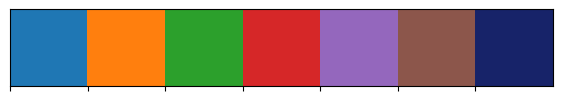

In [2]:
# Palette for visualizations
palette = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#172369"]

# View the palette
sns.palplot(sns.color_palette(palette))

📗📘📙📌 **Importe, limpieza y comcatenación de las bases de datos** 📌📙📘📗

In [28]:
# Importing databases
database_1 = pd.read_csv("https://raw.githubusercontent.com/Sanchez-Juan/Course__Chemoinformatics-applied-to-drug-design/refs/heads/main/app_pubchem.csv") # APP database from PubChem
database_2 = pd.read_csv("https://raw.githubusercontent.com/DIFACQUIM/Cursos/main/Datasets/BIOFACQUIM.V2_curada.csv") # BIOFACQUIM database
database_3 = pd.read_csv("https://raw.githubusercontent.com/DIFACQUIM/Cursos/main/Datasets/FDA_2022_july_05_curada.csv") # FDA-approved drugs

print("🔶 Las columnas que contiene cada base de datos son:")
print(f"- APP database from PubChem: {database_1.columns.tolist()}")
print(f"- BIOFACQUIM database: {database_2.columns.tolist()}")
print(f"- FDA-approved drugs: {database_3.columns.tolist()}")
print(f"\n🔷 El número de compuestos en cada base de datos es: APP-PubChem: {database_1.shape[0]}, BIOFACQUIM: {database_2.shape[0]}, FDA-approved drugs: {database_3.shape[0]}")

🔶 Las columnas que contiene cada base de datos son:
- APP database from PubChem: ['Molecule_id', 'Activity Value [nM]', 'SMILES', 'Molecules', 'MW', 'HBA', 'HBD', 'logP', 'TPSA', 'CSP3', 'NumRings', 'HetAtoms', 'RotBonds', 'Murcko_SMILES', 'Scaffold', 'Source']
- BIOFACQUIM database: ['ID', 'SMILES', 'Data set']
- FDA-approved drugs: ['ID', 'SMILES', 'NEW_SMILES', 'Data set']

🔷 El número de compuestos en cada base de datos es: APP-PubChem: 1475, BIOFACQUIM: 531, FDA-approved drugs: 2309


In [29]:
# Renaming and selecting relevant columns in order to concatenate the databases
database_1 = database_1[["Molecule_id", "SMILES", "Source"]]
database_1 = database_1.rename(columns={"Source": "Dataset"})

database_2 = database_2.rename(columns={"ID": "Molecule_id", "Data set": "Dataset"})

database_3 = database_3[["ID", "NEW_SMILES", "Data set"]]
database_3 = database_3.rename(columns={"ID": "Molecule_id", "NEW_SMILES": "SMILES", "Data set": "Dataset"})

In [30]:
# Concatenating the three databases into a single dataframe
data = pd.concat([database_1, database_2, database_3], ignore_index=True)

# Dropping duplicates based on the "SMILES" column
data = data.drop_duplicates(subset="SMILES").reset_index(drop=True)
print(f"🔷 El número total de compuestos en la base de datos combinada es: {data.shape[0]}")
data.sample(5)

🔷 El número total de compuestos en la base de datos combinada es: 4277


,Molecule_id,SMILES,Dataset
790,5281600,C1=CC(=CC=C1C2=CC(=O)C3=C(O2)C(=C(C=C3O)O)C4=C...,PubChem
3162,DB01718,CCCCCCCCCCCCCCCC[N+](C)(C)C,FDA
1350,162652776,C1=CC=C2C(=C1)C(=CC=N2)NC3=CC=C(C=C3)C(=O)NO,PubChem
1800,FQNP470,CC(=O)CCCCCCCCCCCCCCc1ccccc1,BIOFACQUIM
3639,DB09185,CCOc1ccccc1OCC1CNCCO1,FDA


📗📘📙📌 **Cálculo de descriptores** 📌📙📘📗

[22:40:05] Explicit valence for atom # 7 P, 7, is greater than permitted
[22:40:05] Explicit valence for atom # 30 P, 7, is greater than permitted
[22:40:05] Explicit valence for atom # 15 P, 7, is greater than permitted
[22:40:05] Explicit valence for atom # 15 P, 7, is greater than permitted
[22:40:05] Explicit valence for atom # 5 P, 7, is greater than permitted
[22:40:05] Explicit valence for atom # 11 P, 7, is greater than permitted
[22:40:05] Explicit valence for atom # 1 P, 7, is greater than permitted
[22:40:05] Explicit valence for atom # 3 P, 7, is greater than permitted
[22:40:05] Explicit valence for atom # 6 P, 7, is greater than permitted
[22:40:05] Explicit valence for atom # 11 P, 7, is greater than permitted
[22:40:05] Explicit valence for atom # 1 P, 7, is greater than permitted
[22:40:05] Explicit valence for atom # 4 P, 7, is greater than permitted
[22:40:05] Explicit valence for atom # 1 P, 7, is greater than permitted
[22:40:05] Explicit valence for atom # 3 P, 7,

,Molecule_id,SMILES,Dataset,Molecules,HBA,HBD,RotBonds,logP,TPSA,MW
1335,145954662,CC1=CC=C(C=C1)NC2=NC(=NC(=N2)N3CCN(CC3)C4=CC(=...,PubChem,,11,2,6,4.53244,112.29,545.196696
3412,DB06764,c1ccc2c(c1)CCCC2C1=NCCN1,FDA,,2,1,1,2.10820,24.39,200.131349

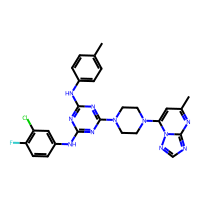
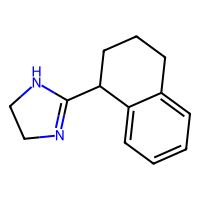

In [31]:
# Adding a column with the 2d structures of the molecules
data["Molecules"] = data["SMILES"].apply(lambda x: Chem.MolFromSmiles(x))
data = data.dropna(subset=['Molecules'])

# Calculation of descriptors of interest for the analysis
data["HBA"] = data["Molecules"].apply(Descriptors.NumHAcceptors)
data["HBD"] = data["Molecules"].apply(Descriptors.NumHDonors)
data["RotBonds"] = data["Molecules"].apply(Descriptors.NumRotatableBonds)
data["logP"] = data["Molecules"].apply(Descriptors.MolLogP)
data["TPSA"] = data["Molecules"].apply(Descriptors.TPSA)
data["MW"] = data["Molecules"].apply(Descriptors.ExactMolWt)
data.sample(2)

📗📘📙📌 **Filtrado y normalización de los datos** 📌📙📘📗

In [32]:
# Selecting the columns of interest for the analysis
dataset = data[["Dataset", "HBA", "HBD", "RotBonds", "logP", "TPSA", "MW"]]

# Creating a dataframe with only the descriptors for scaling and the label for the dataset
descriptors = dataset[["HBA", "HBD", "RotBonds", "logP", "TPSA", "MW"]]
label = dataset["Dataset"]

# z-score: mean = 0 std = 1 - z = x-mean/std
scale = StandardScaler()

# Scaling the descriptor data
scaled_array_descriptors = scale.fit_transform(descriptors) # The result is a numpy array!!! 

# Creating a new dataframe with the scaled descriptors
scaled_descriptors = pd.DataFrame(scaled_array_descriptors, columns=descriptors.columns)

# Verification of the scaled data
scaled_descriptors.describe()

,HBA,HBD,RotBonds,logP,TPSA,MW
count,4.219000e+03,4.219000e+03,4.219000e+03,4.219000e+03,4.219000e+03,4.219000e+03
mean,6.652391e-17,-3.368299e-17,-1.347320e-17,-1.077856e-16,-1.010490e-17,8.420748e-18
std,1.000119e+00,1.000119e+00,1.000119e+00,1.000119e+00,1.000119e+00,1.000119e+00
min,-9.316265e-01,-5.666609e-01,-6.874918e-01,-2.873684e+01,-7.816953e-01,-1.334246e+00
25%,-4.272163e-01,-3.161903e-01,-4.528308e-01,-3.932009e-01,-3.568736e-01,-4.277333e-01
50%,-9.094288e-02,-6.571961e-02,-2.181697e-01,7.943653e-02,-1.538633e-01,-1.258767e-01
75%,7.719385e-02,1.847511e-01,1.338219e-01,4.978673e-01,9.118556e-02,2.035196e-01
max,3.118249e+01,2.848794e+01,1.996268e+01,5.162795e+00,2.489714e+01,2.296063e+01


📗📘📙📌 **Modelo PCA** 📌📙📘📗

In [ ]:
# PCA analysis
pca = PCA(n_components=2)  # Number of principal components to keep
pca_data = pca.fit_transform(scaled_array_descriptors)  # Using the scaled array of descriptors for PCA

# Explained variance ratio
explained_variance = pca.explained_variance_ratio_
print(f"🔶 Varianza explicada: {explained_variance.sum():.2f}")

🔶 Varianza explicada: 1.00


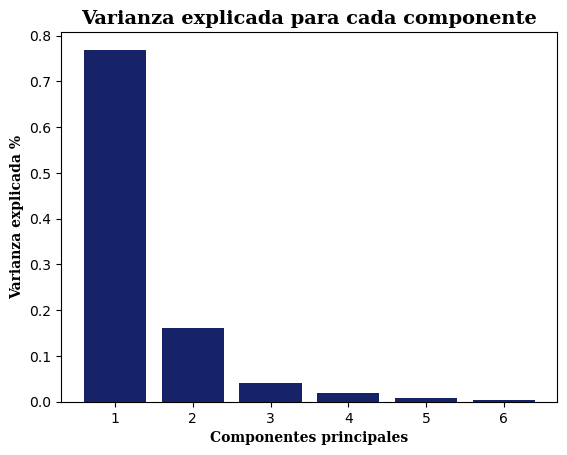

In [62]:
# Explained variance for each principal component
plt.bar(range(1, pca.n_components_ + 1), explained_variance, color=palette[6])

# Labels
plt.title('Varianza explicada para cada componente', fontsize = 14, fontweight='bold', fontfamily='serif')
plt.xlabel('Componentes principales', fontsize = 10, fontweight='bold', fontfamily='serif')
plt.ylabel('Varianza explicada %', fontsize = 10, fontweight='bold', fontfamily='serif')
plt.show()

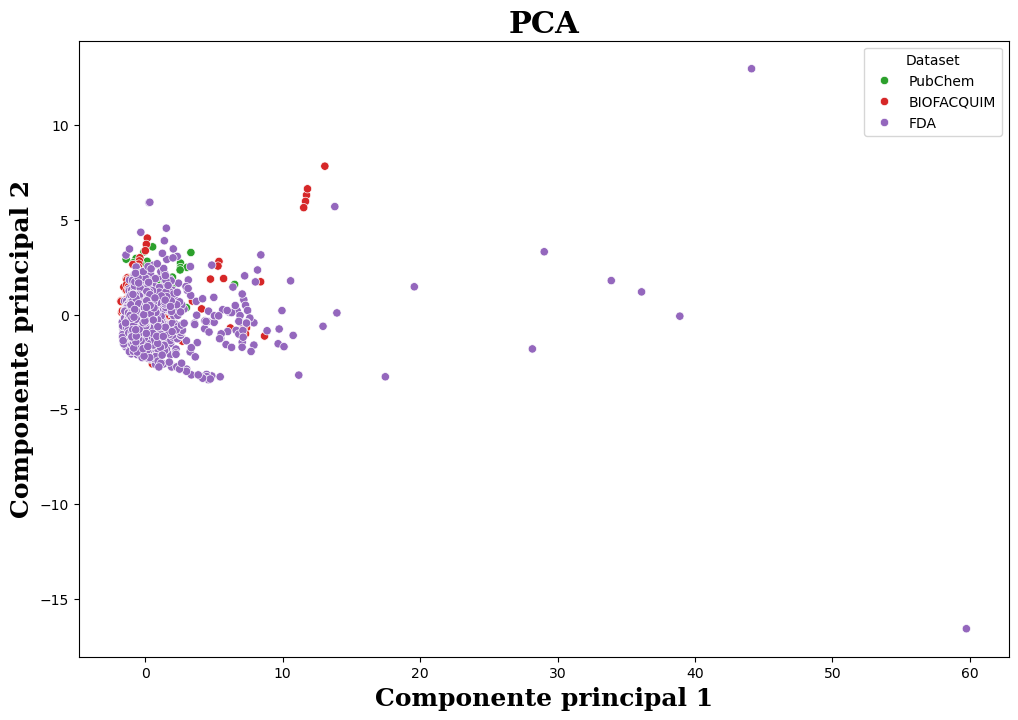

In [77]:
# PCA graph
plt.figure(figsize=(12, 8))
sns.scatterplot(x = pca_data[:, 0], y = pca_data[:, 1], hue=label, palette=palette[2:5])

# Labels
plt.title('PCA', fontsize = 22, fontweight='bold', fontfamily='serif')
plt.xlabel('Componente principal 1', fontsize = 18, fontweight='bold', fontfamily='serif')
plt.ylabel('Componente principal 2', fontsize = 18, fontweight='bold', fontfamily='serif')
plt.show()

📗📘📙📌 **Modelo t-SNE** 📌📙📘📗

In [68]:
# t-SNE analysis
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)

tsne_data = tsne.fit_transform(scaled_array_descriptors)

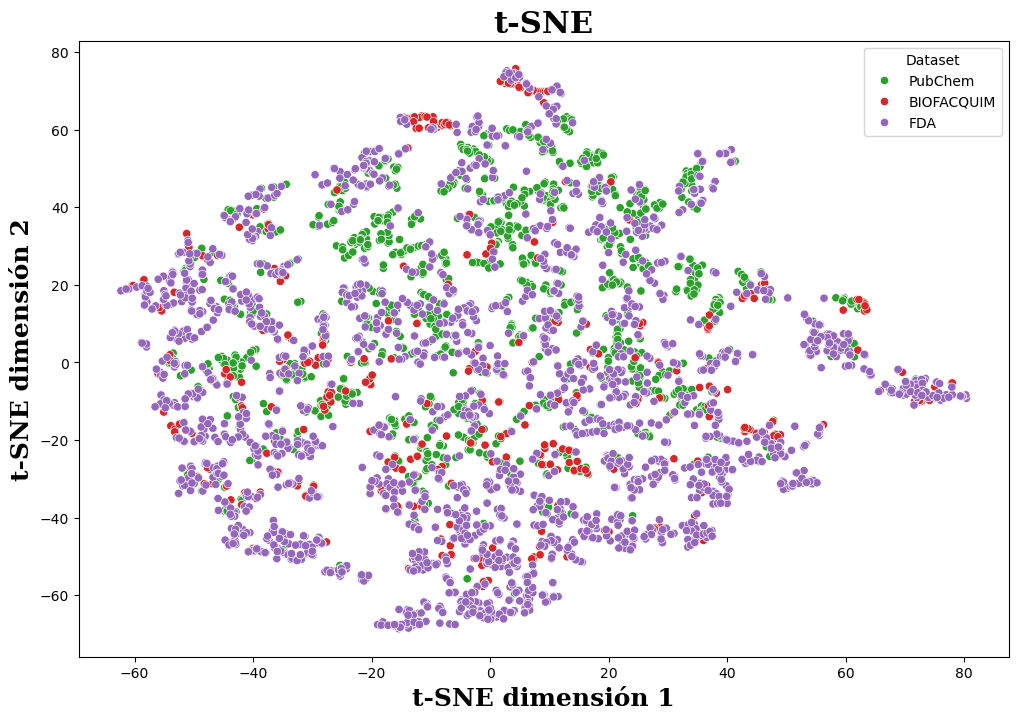

In [76]:
# t-SNE graph
plt.figure(figsize=(12, 8))

sns.scatterplot(x = tsne_data[:,0], y = tsne_data[:,1], hue=label, palette=palette[2:5])

# Labels
plt.title('t-SNE', fontsize = 22, fontweight='bold', fontfamily='serif')
plt.xlabel('t-SNE dimensión 1', fontsize = 18, fontweight='bold', fontfamily='serif')
plt.ylabel('t-SNE dimensión 2', fontsize = 18, fontweight='bold', fontfamily='serif')

plt.show()